# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [2]:
#reading the vehicles dataset and printing the first five rows
df = pd.read_csv('data/vehicles.csv')

In [3]:
#print first five rows of the data
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
#print the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [5]:
#lets describe the dataset
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,426880.0,NaN,NaN,NaN,7311486634.224333,4473170.412559,7207408119.0,7308143339.25,7312620821.0,7315253543.5,7317101084.0
region,426880,404,columbus,3608,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,426880.0,NaN,NaN,NaN,75199.033187,12182282.173598,0.0,5900.0,13950.0,26485.75,3736928711.0
year,425675.0,NaN,NaN,NaN,2011.235191,9.45212,1900.0,2008.0,2013.0,2017.0,2022.0
manufacturer,409234,42,ford,70985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,421603,29649,f-150,8009,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,252776,6,good,121456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cylinders,249202,8,6 cylinders,94169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel,423867,5,gas,356209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
odometer,422480.0,NaN,NaN,NaN,98043.331443,213881.500798,0.0,37704.0,85548.0,133542.5,10000000.0


In [6]:
#Let's try to find some unique values in some columns
print("Unique values in 'condition' column:", df['condition'].unique())
print("Unique values in 'title_status' column:", df['title_status'].unique())
print("Unique values in 'fuel' column:", df['fuel'].unique())
print("Unique values in 'size' column:", df['size'].unique())
print("Unique values in 'drive' column:", df['drive'].unique())
print("Unique values in 'type' column:", df['type'].unique())

Unique values in 'condition' column: [nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']
Unique values in 'title_status' column: [nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']
Unique values in 'fuel' column: [nan 'gas' 'other' 'diesel' 'hybrid' 'electric']
Unique values in 'size' column: [nan 'full-size' 'mid-size' 'compact' 'sub-compact']
Unique values in 'drive' column: [nan 'rwd' '4wd' 'fwd']
Unique values in 'type' column: [nan 'pickup' 'truck' 'other' 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'van' 'convertible' 'wagon']


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

1. Drop/clean identifiers

In [7]:
#dropping Id and VIN columns as they are not useful for our analysis
df = df.drop(columns=['id', 'VIN'])

2. Fix datatypes and simple cleaning

In [8]:
#As we can see year is float let's convert to int if safe
df['year'] = df['year'].astype('Int64')
df['odometer'] = df['odometer'].astype(float)

3. Handle missing values & Outlier treatment

In [9]:
#Remove zero or negative prices (if any)
df = df[df['price'] > 0]
df['log_price'] = np.log1p(df['price'])

4. Feature Engineering

In [10]:
#Let's identify Age of each vehicle and create a new column 'age'
current_year = 2025
df['age'] = current_year - df['year']

In [11]:
#Add another feature for mileage per year
df['miles_per_year'] = df['odometer'] / df['age'].replace(0, np.nan)  # avoid division by zero

#Add feature for is_automatic based on transmission type
df['is_automatic'] = df['transmission'].str.lower().str.contains('auto', case=False, na=False).astype(int)

#Add feature for is salvaged based on title_status
df['is_salvage'] = df['title_status'].str.lower().str.contains('salvage|rebuilt', case=False, na=False).astype(int)

df.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,drive,size,type,paint_color,state,log_price,age,miles_per_year,is_automatic,is_salvage
0,prescott,6000,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,az,8.699681,<NA>,<NA>,0,0
1,fayetteville,11900,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,ar,9.384378,<NA>,<NA>,0,0
2,florida keys,21000,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,fl,9.952325,<NA>,<NA>,0,0
3,worcester / central MA,1500,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,ma,7.313887,<NA>,<NA>,0,0
4,greensboro,4900,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,nc,8.497195,<NA>,<NA>,0,0


5. Encoding categorical variables

Different strategies for different columns:

Low-cardinality (e.g., condition, fuel, transmission, drive, size, type, title_status, paint_color if not too many): One-hot encoding.

High-cardinality (e.g., model, sometimes manufacturer): frequency encoding or target encoding

In [12]:
# Factorize — gives integer labels and mapping
df['manufacturer_code'], manuf_mapping = pd.factorize(df['manufacturer'])
# or
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['condition_code'] = le.fit_transform(df['condition'].astype(str))

# Frequency encoding
freq = df['model'].value_counts(normalize=True)
df['model_freq'] = df['model'].map(freq)

# Target encoding (example using mean price) -- do inside Cross Validation (CV) to avoid leakage
mean_price_by_model = df.groupby('model')['price'].mean()
df['model_target_mean'] = df['model'].map(mean_price_by_model)

6. Final feature list

In [13]:
features = [
    'age','odometer','miles_per_year','manufacturer_code','model_freq',
    'condition_code','cylinders','fuel','is_automatic','is_salvage','drive','size','type','paint_color','state'
]

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

1. Baseline Models
    - Linear Regression with log_price, interpretable coefficients.
    - Regularized Linear Models (Ridge/Lasso) to handle correlated features.

In [14]:
num_cols = ['age', 'odometer', 'miles_per_year']
cat_cols = [
    'manufacturer','condition','cylinders','fuel',
    'transmission','drive','type','state'
]  

In [15]:
for c in cat_cols:
    if c not in df.columns:
        df[c] = 'missing'
    df[c] = df[c].fillna('missing').astype(str)

X = df[num_cols + cat_cols]
y = df['log_price']

In [16]:
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("num", num_pipe, num_cols),
                                ("cat", cat_pipe, cat_cols)])

In [17]:
# Models to compare
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=5000)
    #"RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
}

In [18]:
# Train/test split (fast and stable)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print("Train/test sizes:", X_train.shape[0], X_test.shape[0])

Train/test sizes: 275789 118196


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [27]:
def rmse(y_true, y_pred):
    # compute RMSE directly without relying on sklearn.metrics.mean_squared_error
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

fitted = {}

# replace these names if your fitted objects use different variables
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.0005, max_iter=5000)
    #"RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
}

In [28]:
results = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    root_mse = rmse(y_test, preds)  # on log-price
    r2 = r2_score(y_test, preds)
    results.append({"model": name, "rmse_log_price": root_mse, "r2": r2})
    fitted[name] = pipe
    print(f"{name}: RMSE (log-price)={root_mse:.4f}, R2={r2:.4f}")

results_df = pd.DataFrame(results)
print("\nModel results :\n", results_df)

LinearRegression: RMSE (log-price)=1.1818, R2=0.0907
Ridge: RMSE (log-price)=1.2247, R2=0.0234
Lasso: RMSE (log-price)=1.0677, R2=0.2578

Model results :
               model  rmse_log_price        r2
0  LinearRegression        1.181754  0.090714
1             Ridge        1.224726  0.023383
2             Lasso        1.067653  0.257825


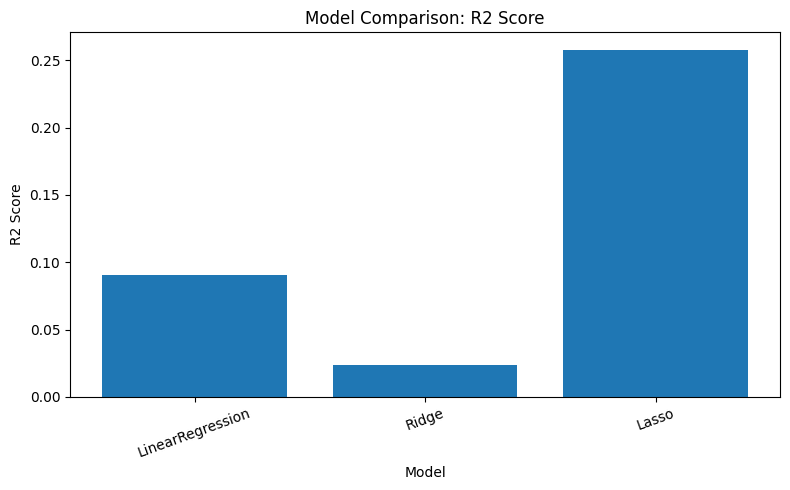

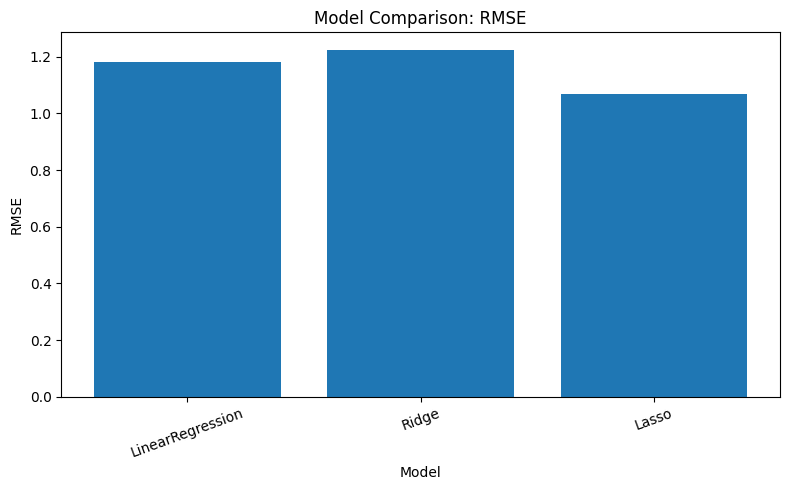

In [29]:
# -----------------------------
# VISUALIZATIONS
# -----------------------------

# ---- R2 Comparison ----
plt.figure(figsize=(8,5))
plt.bar(results_df["model"], results_df["r2"])
plt.title("Model Comparison: R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ---- RMSE Comparison ----
plt.figure(figsize=(8,5))
plt.bar(results_df["model"], results_df["rmse_log_price"])
plt.title("Model Comparison: RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

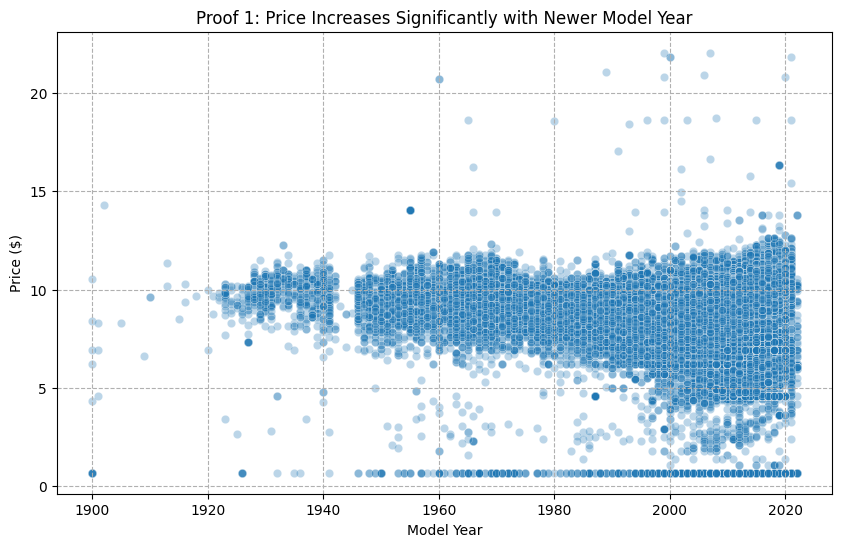

In [36]:
# 1: Prioritize Age (Year is Key) ---
# Scatter plot to show the linear relationship between Year and Price.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='year', y='log_price', data=df, alpha=0.3)
plt.title('Proof 1: Price Increases Significantly with Newer Model Year')
plt.xlabel('Model Year')
plt.ylabel('Price ($)')
plt.grid(True, linestyle='--')
plt.savefig('proof_1_year_vs_price.png')
plt.show()

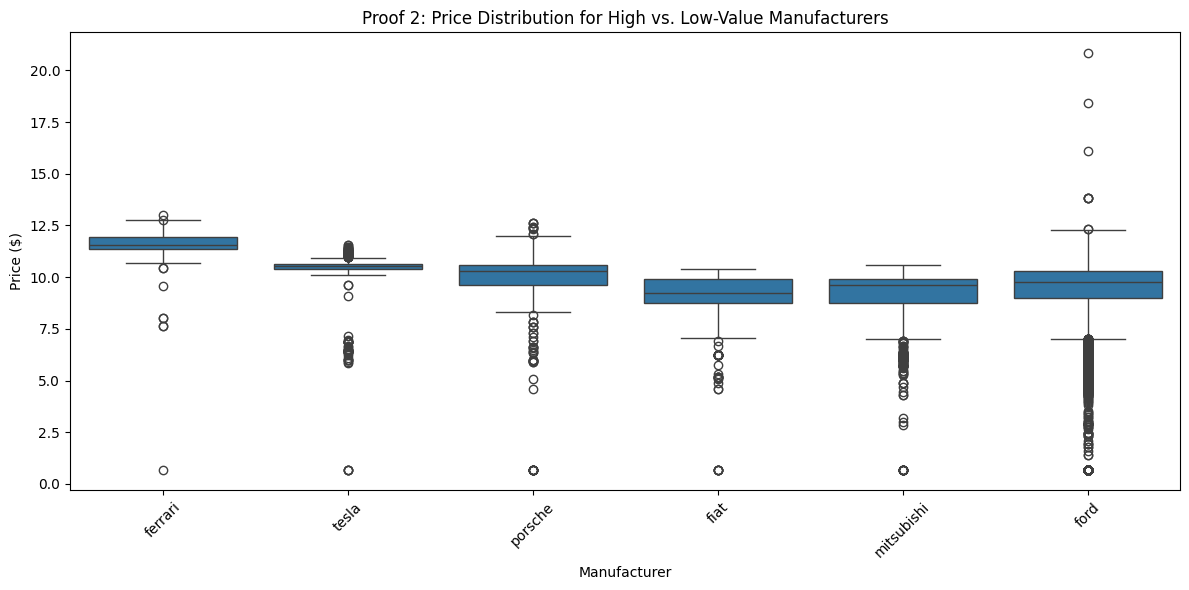

In [ ]:
# 2: Target High-End Manufacturers ---
# Boxplot comparing the distribution of prices for the most influential positive and negative manufacturers.
high_value_manufacturers = ['ferrari', 'tesla', 'porsche']
low_value_manufacturers = ['fiat', 'mitsubishi']
baseline_manufacturer = ['ford'] # Add a common manufacturer for context

# Combine selected manufacturers and filter the data
selected_manufacturers = high_value_manufacturers + low_value_manufacturers + baseline_manufacturer
df_manufacturers = df[df['manufacturer'].isin(selected_manufacturers)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='manufacturer', y='log_price', data=df_manufacturers, 
            order=selected_manufacturers)
plt.title('Proof 2: Price Distribution for High vs. Low-Value Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('proof_2_high_low_manufacturers_price.png')
plt.show()

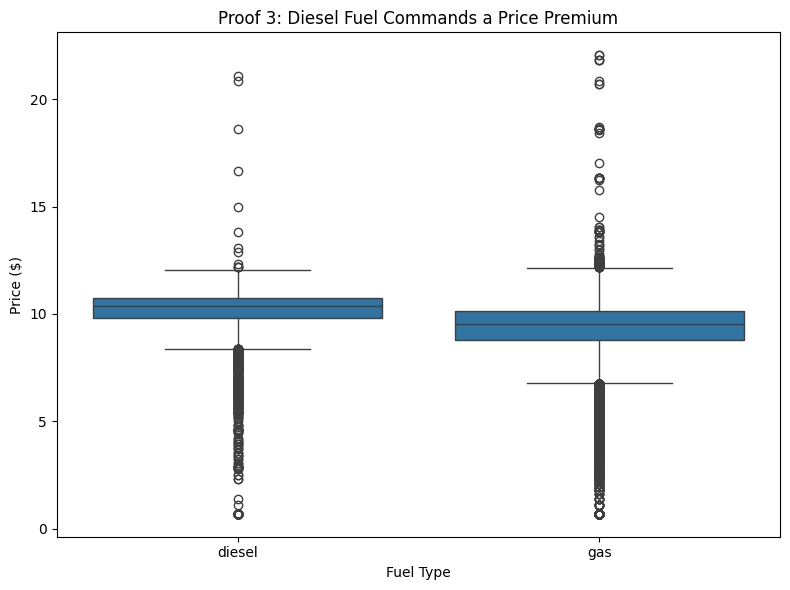

In [37]:
#3: Value Diesel Fuel ---
# Boxplot comparing Diesel fuel type against the highest volume fuel type (likely Gas)
df_fuel = df[df['fuel'].isin(['diesel', 'gas'])]

plt.figure(figsize=(8, 6))
sns.boxplot(x='fuel', y='log_price', data=df_fuel, order=['diesel', 'gas'])
plt.title('Proof 3: Diesel Fuel Commands a Price Premium')
plt.xlabel('Fuel Type')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.savefig('proof_3_diesel_vs_gas_price.png')
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

Based on the feature analysis, here are some recommendations for the used-car dealership client: 

1. Prioritize Age Over Mileage (Year is the Key)
    - Lasso method proves that "Year" was a highly influential positive factor. The scatter plot confirms this as model year increases (newer cars), the maximum and median price of the cars tends to rise clearly.
2. Target High-End Manufacturers
    - The box plot above clearly indicates high end manufacturer prices, their mean and median proces tends to rise higher then the average/normal manaufacturer such as "ford"
3. Value Diesel Fuel cars
    - The third plot which is also a box plot between cars of Diesel fuel versus Gas clearly indicated that Diesel Cars have higher prices and hence those are the ones the car-dealership should prioritize over gas fuel type cars